<a href="https://colab.research.google.com/github/Priya9823/Dublin-Airbnb-Market-Analysis/blob/main/youtube.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
!pip install pandas
import pandas as pd
rising = pd.read_csv("/content/drive/MyDrive/projects1/searched_with_rising-queries_IE_20250520-0205_20260520-0205.csv")
TOP = pd.read_csv("/content/drive/MyDrive/projects1/searched_with_top-queries_IE_20250520-0205_20260520-0205.csv")
Timings = pd.read_csv("/content/drive/MyDrive/projects1/time_series_IE_20250520-0204_20260520-0204.csv")

In [36]:
rising = rising.reset_index(drop = True)
TOP.head()

,query,search interest,increase percent
0,youtube youtube,100,2%
1,youtube,97,2%
2,on youtube,22,9%
3,youtube channel,11,-10%
4,shorts,8,20%


In [37]:
rising.head()

,query,search interest,increase percent
0,preston journalist,0,Breakout
1,scott ritter youtube,0,Breakout
2,dalscone farm youtube,0,Breakout
3,silver fox hot takes youtube,0,"2,450%"
4,youtube wrapped,0,300%


In [38]:
rising = rising.rename(columns =
 {'query' : 'Query',
  'search interest':'Serach_Intrest',
  'increase percent' : 'Increase_percent' })
print(rising.columns)
TOP = TOP.rename(columns={'query':'query','search interest':'search_interest',
                          'increase percent':'increase_percent'})
TOP.columns

Index(['Query', 'Serach_Intrest', 'Increase_percent'], dtype='object')


Index(['query', 'search_interest', 'increase_percent'], dtype='object')

In [39]:
rising = rising.dropna(subset=['Serach_Intrest'])
rising = rising[rising['Serach_Intrest'] > 0]

In [40]:
rising.shape
rising.head()

,Query,Serach_Intrest,Increase_percent
15,tg4 youtube,1,70%
23,free movies on youtube full movies,3,60%
25,youtube free movies,5,40%
26,free movies on youtube,4,40%
29,films on youtube,1,40%


In [41]:
rising = rising.reset_index(drop = True )

In [42]:
rising.head()

,Query,Serach_Intrest,Increase_percent
0,tg4 youtube,1,70%
1,free movies on youtube full movies,3,60%
2,youtube free movies,5,40%
3,free movies on youtube,4,40%
4,films on youtube,1,40%


In [43]:
def top_serach(Query):
 r = rising[rising['Query'].str.contains(Query)]
 r = r.sort_values('Serach_Intrest', ascending = False)
 return r
 print(r)
top_serach('movies')
top_serach('films')

,Query,Serach_Intrest,Increase_percent
4,films on youtube,1,40%
5,youtube films,1,40%


In [44]:
top_ten = rising.sort_values('Serach_Intrest',ascending = False).head(10)
print(top_ten)

                                 Query  Serach_Intrest Increase_percent
8                               shorts               8              20%
11                      youtube movies               7              20%
2                  youtube free movies               5              40%
6                    movies on youtube               5              30%
7                          free movies               4              30%
3               free movies on youtube               4              40%
12                        kids youtube               4              20%
10                                  yt               4              20%
13                        youtube kids               4              20%
1   free movies on youtube full movies               3              60%


In [63]:
Timings.describe()

,YouTube
count,53.000000
mean,85.603774
std,7.365041
min,66.000000
25%,83.000000
50%,85.000000
75%,91.000000
max,100.000000


In [46]:
TOP.head()

,query,search_interest,increase_percent
0,youtube youtube,100,2%
1,youtube,97,2%
2,on youtube,22,9%
3,youtube channel,11,-10%
4,shorts,8,20%


In [47]:
TOP = TOP.dropna(subset=['search_interest'])
TOP = TOP[TOP['search_interest'] > 0]
TOP.head()

,query,search_interest,increase_percent
0,youtube youtube,100,2%
1,youtube,97,2%
2,on youtube,22,9%
3,youtube channel,11,-10%
4,shorts,8,20%


In [58]:
TOP = TOP.sort_values('search_interest',ascending = False)
top_50 = TOP.head(10)

In [49]:
!pip install matplotlib
import matplotlib.pyplot as plt


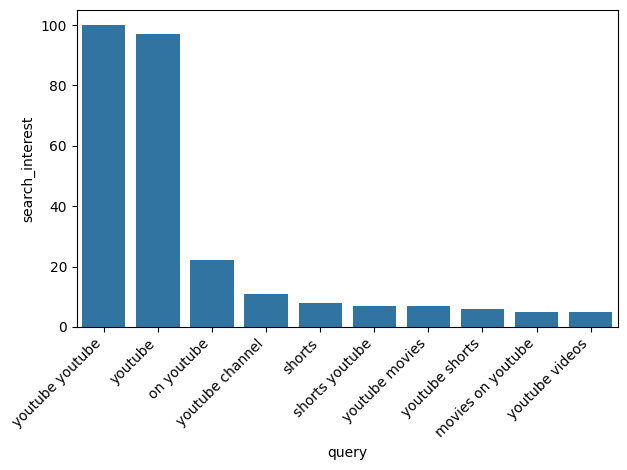

In [60]:
!pip install seaborn
import seaborn as sns
sns.barplot(data=top_50, x='query', y='search_interest')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

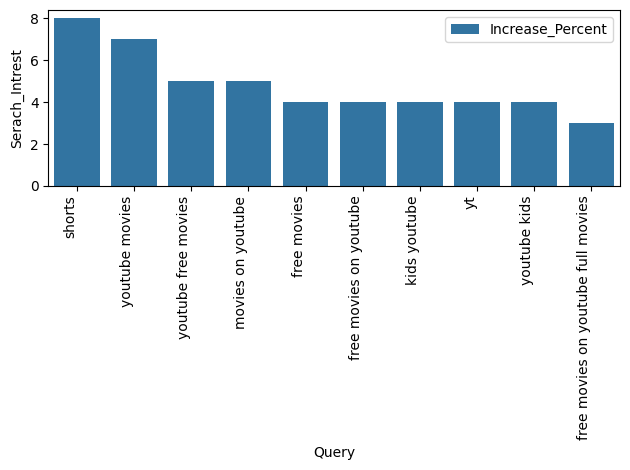

In [62]:
sns.barplot(data=top_ten, x='Query', y='Serach_Intrest', label='Increase_Percent')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

,YouTube
Time,
2025-05-18,85
2025-05-25,90
2025-06-01,85
2025-06-08,86
2025-06-15,86


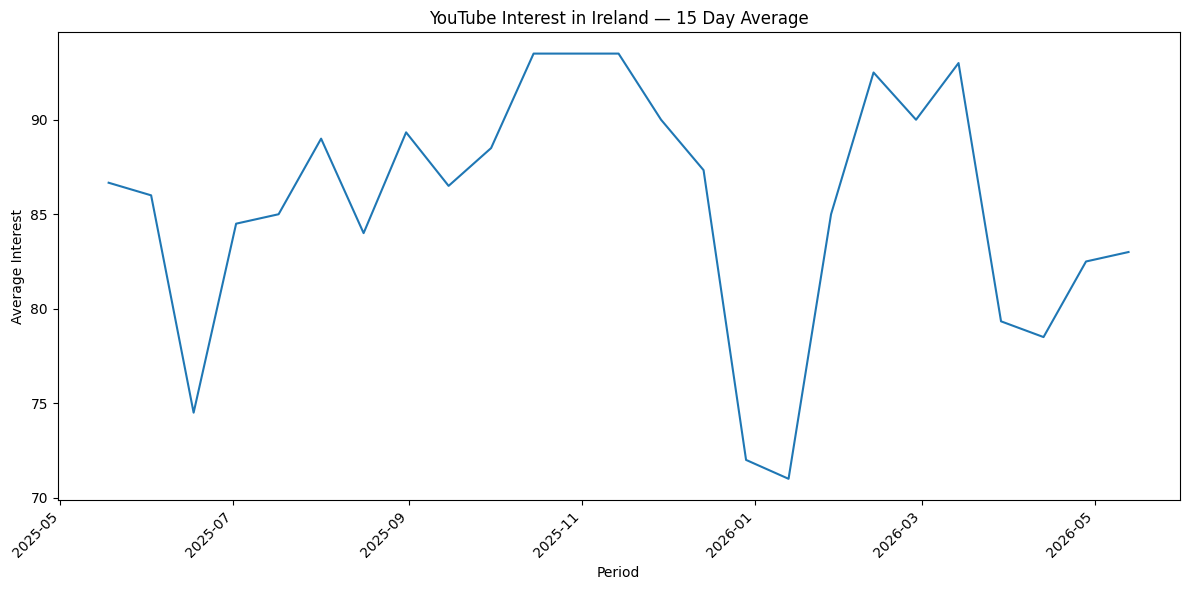

In [78]:
#Timings['Time'] =pd.to_datetime(Timings['Time'])
#Timings = Timings.set_index('Time')
Timings_15day = Timings.resample('15D').mean()
plt.figure(figsize=(12, 6))
plt.plot(Timings_15day.index, Timings_15day['YouTube'])
plt.title('YouTube Interest in Ireland — 15 Day Average')
plt.xlabel('Period')
plt.ylabel('Average Interest')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
Timings.head()